# Nigerian SME Segmentation - Modelling

**Dataset:** `data/processed/sme_clean.csv` - 1,043 firms, 21 features  
**Goal:** Identify meaningful SME segments using unsupervised learning  
**Methods:** StandardScaler, PCA, K-Means, Hierarchical Clustering  

This notebook picks up from `eda.ipynb` where the dataset was cleaned and saved.  

---

## 1. Imports and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/processed/sme_clean.csv')

print(df.shape)
df.head()

(1043, 21)


,l1,k3a,k3bc,k3f,d3c,d12b,b5,b7,k82a,b8,h1,h8,c22b,e6,e11,b4,k30,c30a,j30a,e30,sales_growth
0,1.448822,70.0,10.0,20.0,0.0,0.0,2016.0,1.271150,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,3.0,1.0,0.032220
1,1.489299,100.0,0.0,0.0,0.0,0.0,2005.0,1.397363,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.011319
2,1.124748,60.0,0.0,20.0,0.0,0.0,2008.0,1.358505,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,3.0,2.0,2.0,0.017858
3,1.223156,60.0,0.0,0.0,0.0,0.0,2012.0,1.327761,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0,1.0,4.0,0.050165
4,1.162283,100.0,0.0,0.0,0.0,100.0,1969.0,1.327761,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,2.0,-0.007484


## 2. Feature Scaling

Before any distance-based algorithm, all features must be on the same scale.  
StandardScaler brings every feature to mean=0 and std=1.

Without this, features with the largest raw variance would dominate distance  
calculations regardless of their actual importance. Even after log-transforming  
skewed features in EDA, the raw ranges still differ enough to cause problems.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# wrap back in a dataframe for readability
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print(X_scaled.shape)
X_scaled.describe().round(2)

(1043, 21)


,l1,k3a,k3bc,k3f,d3c,d12b,b5,b7,k82a,b8,h1,h8,c22b,e6,e11,b4,k30,c30a,j30a,e30,sales_growth
count,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00,1043.00
mean,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.09,-2.56,-0.28,-0.54,-0.16,-0.55,-7.19,-3.79,-0.39,-0.36,-0.58,-0.44,-0.78,-0.44,-1.09,-0.55,-1.56,-2.16,-1.48,-1.35,-5.93
25%,-0.76,-0.77,-0.28,-0.54,-0.16,-0.55,-0.38,-0.61,-0.39,-0.36,-0.58,-0.44,-0.78,-0.44,-1.09,-0.55,-0.82,-0.48,-0.60,-0.51,-0.29
50%,-0.15,0.31,-0.28,-0.54,-0.16,-0.55,0.33,0.08,-0.39,-0.36,-0.58,-0.44,-0.78,-0.44,0.91,-0.55,-0.07,0.36,0.28,-0.51,-0.06
75%,0.67,1.03,-0.28,0.19,-0.16,0.24,0.68,0.76,-0.39,-0.36,1.72,-0.44,1.28,-0.44,0.91,-0.55,0.68,0.36,1.17,0.34,0.23
max,3.11,1.03,10.93,6.72,12.65,3.41,1.31,1.85,2.58,2.77,1.72,2.29,1.28,2.27,0.91,1.83,1.43,1.20,2.05,2.03,6.66


## 3. PCA - Dimensionality Reduction

With 21 features, PCA can potentially reduce noise and collinearity before  
clustering. We run full PCA first to inspect the explained variance curve  
before deciding how many components to keep.

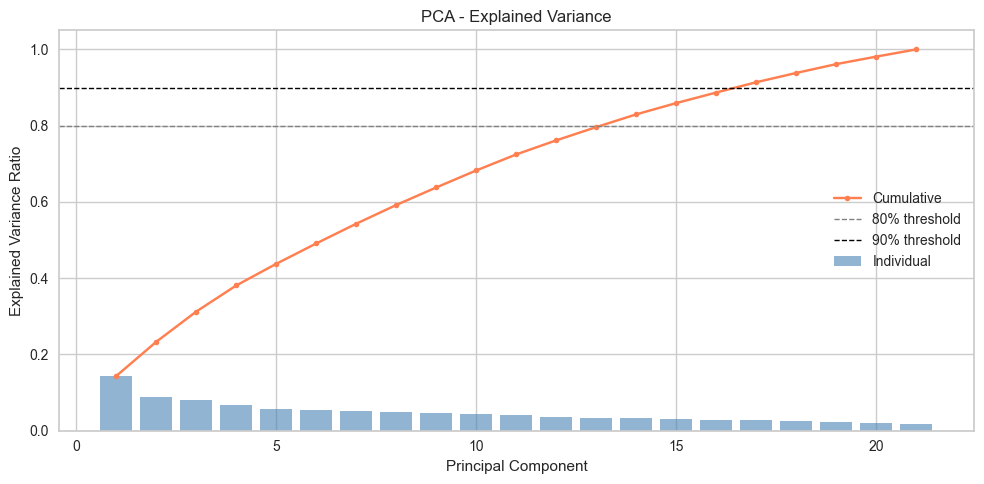

PC01: 0.144 individual | 0.144 cumulative
PC02: 0.090 individual | 0.233 cumulative
PC03: 0.079 individual | 0.313 cumulative
PC04: 0.068 individual | 0.381 cumulative
PC05: 0.057 individual | 0.438 cumulative
PC06: 0.053 individual | 0.491 cumulative
PC07: 0.052 individual | 0.543 cumulative
PC08: 0.049 individual | 0.592 cumulative
PC09: 0.046 individual | 0.638 cumulative
PC10: 0.045 individual | 0.683 cumulative
PC11: 0.042 individual | 0.725 cumulative
PC12: 0.037 individual | 0.762 cumulative
PC13: 0.035 individual | 0.796 cumulative
PC14: 0.033 individual | 0.830 cumulative
PC15: 0.030 individual | 0.859 cumulative
PC16: 0.028 individual | 0.887 cumulative
PC17: 0.027 individual | 0.914 cumulative
PC18: 0.024 individual | 0.938 cumulative
PC19: 0.023 individual | 0.962 cumulative
PC20: 0.020 individual | 0.981 cumulative
PC21: 0.019 individual | 1.000 cumulative


In [4]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.6, 
       color='steelblue', label='Individual')
ax.plot(range(1, len(cumulative)+1), cumulative, 
        color='coral', marker='o', markersize=4, label='Cumulative')
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
ax.axhline(0.90, color='black', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA - Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# print the numbers
for i, (ind, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i:02d}: {ind:.3f} individual | {cum:.3f} cumulative")

**Finding:** Variance is spread almost evenly across all 21 components.  
PC1 explains only 14.4% - very low for a first component. The curve is  
nearly linear with no clear elbow.

- 80% cumulative variance requires 13 components  
- 90% cumulative variance requires 17 components  

Reducing to 13 components barely simplifies the 21-feature problem.  
This means the firms vary across many independent dimensions simultaneously  
rather than along one or two dominant axes. This is typical of survey data.

**Decision:** Use full scaled features for clustering. Apply PCA for 2D  
visualisation only, not as a preprocessing step.

In [5]:
# keep 2 components for 2D cluster visualization later
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"2 components explain: {pca_2d.explained_variance_ratio_.sum():.1%} of variance")
print("Clustering will run on full scaled features, not PCA-reduced data.")

2 components explain: 23.3% of variance
Clustering will run on full scaled features, not PCA-reduced data.


## 4. Choosing the Number of Clusters

We evaluate K=2 through K=9 using three complementary methods:

- **Elbow method** - plots inertia (within-cluster sum of squares) vs K.  
  Look for a bend where adding more clusters gives diminishing returns.
- **Silhouette score** - measures how well each firm fits its cluster vs  
  its nearest neighbour. Higher is better, range -1 to +1.
- **Calinski-Harabasz index** - ratio of between-cluster to within-cluster  
  variance. Higher is better.
- **Davies-Bouldin index** - average similarity between each cluster and  
  its most similar neighbour. Lower is better.

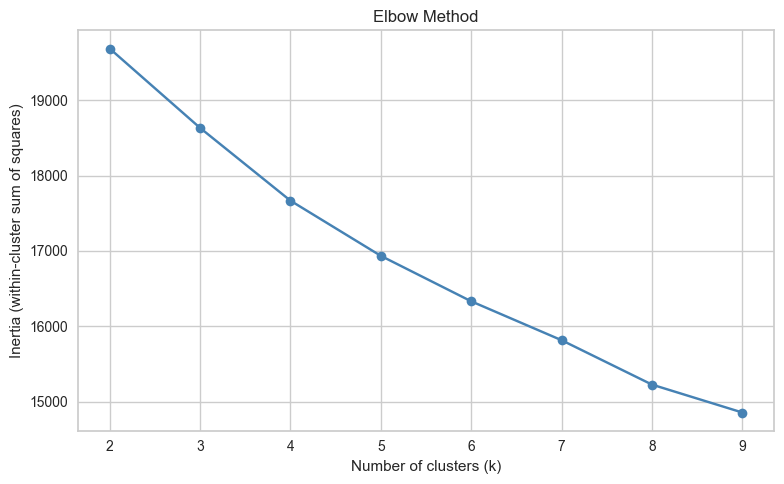

k=2: 19685.66
k=3: 18633.05
k=4: 17667.66
k=5: 16935.72
k=6: 16332.68
k=7: 15816.61
k=8: 15227.69
k=9: 14857.40


In [7]:
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../outputs/figures/elbow.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: {inertia:.2f}")

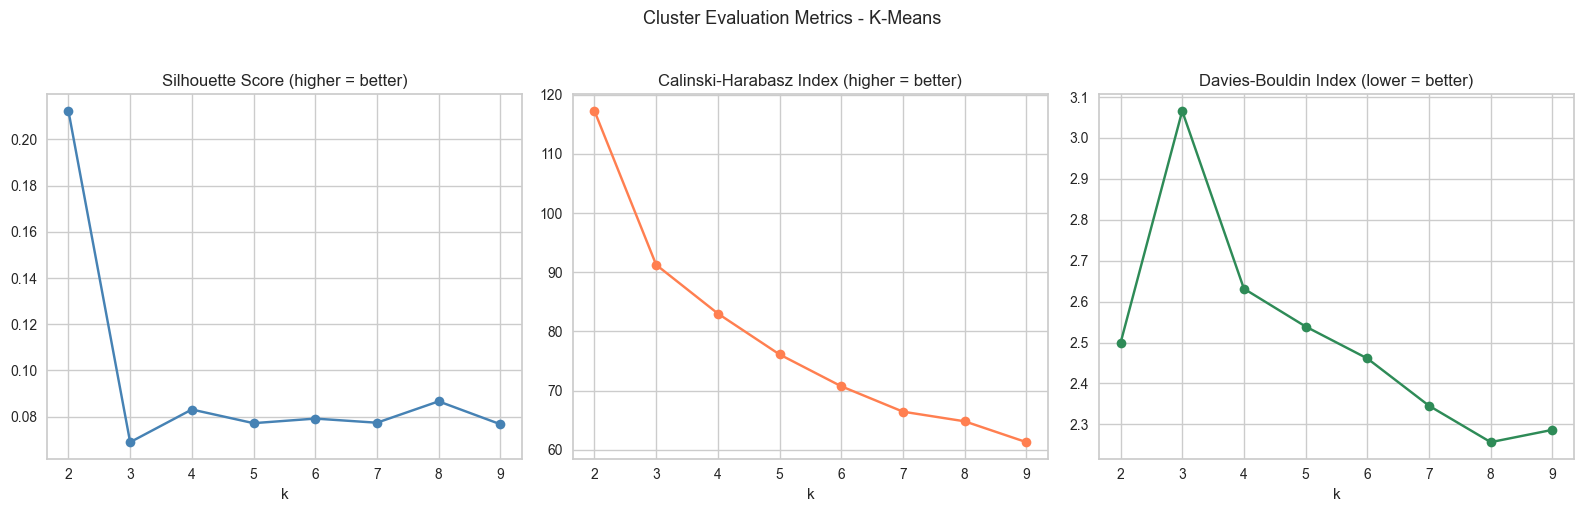

k     Silhouette      CH Index        DB Index  
2     0.2123          117.26          2.4988    
3     0.0689          91.26           3.0659    
4     0.0831          83.02           2.6317    
5     0.0772          76.11           2.5392    
6     0.0791          70.73           2.4612    
7     0.0773          66.44           2.3456    
8     0.0866          64.82           2.2566    
9     0.0767          61.29           2.2867    


In [8]:
silhouette_scores = []
ch_scores = []
db_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(k_range, silhouette_scores, marker='o', color='steelblue')
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].set_xlabel('k')

axes[1].plot(k_range, ch_scores, marker='o', color='coral')
axes[1].set_title('Calinski-Harabasz Index (higher = better)')
axes[1].set_xlabel('k')

axes[2].plot(k_range, db_scores, marker='o', color='seagreen')
axes[2].set_title('Davies-Bouldin Index (lower = better)')
axes[2].set_xlabel('k')

plt.suptitle('Cluster Evaluation Metrics - K-Means', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# print the table
print(f"{'k':<5} {'Silhouette':<15} {'CH Index':<15} {'DB Index':<10}")
for k, s, ch, db in zip(k_range, silhouette_scores, ch_scores, db_scores):
    print(f"{k:<5} {s:<15.4f} {ch:<15.2f} {db:<10.4f}")

**Reading the metrics:**

The elbow chart shows almost no bend - inertia declines nearly linearly  
from K=2 to K=9. No single K stands out mathematically.

| k | Silhouette | CH Index | DB Index |
|---|---|---|---|
| 2 | **0.2123** | **117.26** | 2.4988 |
| 3 | 0.0689 | 91.26 | 3.0659 |
| 4 | 0.0831 | 83.02 | 2.6317 |
| 5 | 0.0772 | 76.11 | 2.5392 |
| 8 | 0.0866 | 64.82 | **2.2566** |

K=2 dominates silhouette and CH but produces only "large vs small firms" -  
too coarse for any business strategy. K=3 is the worst DB score of the range.  
K=8 has the best DB but 8 segments is too many to profile and interpret  
meaningfully.

**Research context:** Atemoagbo et al. (2024) on Nigerian MSMEs chose K=3  
with a silhouette of 0.36 based on interpretability rather than peak metrics.  
They noted that k=2 would score higher statistically but yield less actionable  
segments. The same logic applies here.

**Decision: K=4.** Silhouette recovers from the K=3 dip, DB is acceptable,  
and four segments maps naturally to distinct SME archetypes in the Nigerian  
context. Interpretability drives this choice, not a single metric peak.

## 5. K-Means at K=4

In [9]:
km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
df['cluster'] = km.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print(f"\nInertia: {km.inertia_:.2f}")

Cluster sizes:
cluster
0     66
1    151
2    274
3    552
Name: count, dtype: int64

Inertia: 17667.66


### Silhouette Analysis

A per-firm silhouette plot shows how well each firm sits within its assigned  
cluster. Firms with negative scores are closer to a neighbouring cluster  
than their own - a sign of weak separation at the individual level.

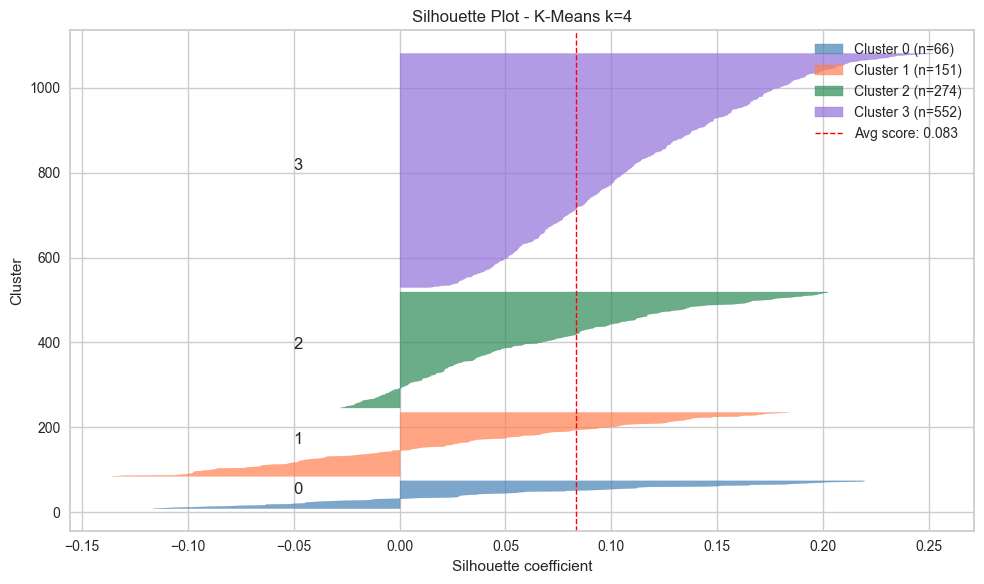


Average silhouette score: 0.0831

Per-cluster average:
  Cluster 0: 0.0451 (n=66)
  Cluster 1: 0.0253 (n=151)
  Cluster 2: 0.0619 (n=274)
  Cluster 3: 0.1140 (n=552)


In [12]:
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X_scaled, df['cluster'])
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
for i in range(4):
    cluster_sil_vals = np.sort(silhouette_vals[df['cluster'] == i])
    size = len(cluster_sil_vals)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     alpha=0.7, color=colors[i], label=f'Cluster {i} (n={size})')

    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, df['cluster'])
ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1,
           label=f'Avg score: {avg_score:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot - K-Means k=4')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/figures/silhouette_k4.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage silhouette score: {avg_score:.4f}")
print("\nPer-cluster average:")
for i in range(4):
    vals = silhouette_vals[df['cluster'] == i]
    print(f"  Cluster {i}: {vals.mean():.4f} (n={len(vals)})")

**Reading the silhouette plot:**

- Cluster 3 (n=552) is the strongest at 0.114 - the large dominant group  
  is the most internally coherent
- Cluster 0 (n=66) and Cluster 1 (n=151) are weakest with some negative  
  scores - some firms in these clusters sit closer to neighbours
- Average score of 0.083 is low but consistent with multi-dimensional  
  survey data where firms overlap across many dimensions simultaneously

This is a data characteristic, not a modelling failure. The variance chart  
already showed no dominant axis. Firms do not sort into tight boxes in reality  
and the silhouette reflects that honestly. The profiling step will show whether  
the centroids tell a meaningful business story despite the moderate separation.

### 2D PCA Visualisation

Project clusters onto the first two principal components (23.3% of variance)  
to get a visual sense of how the four segments sit relative to each other.  
This is a rough picture - only 23.3% of variance is shown.

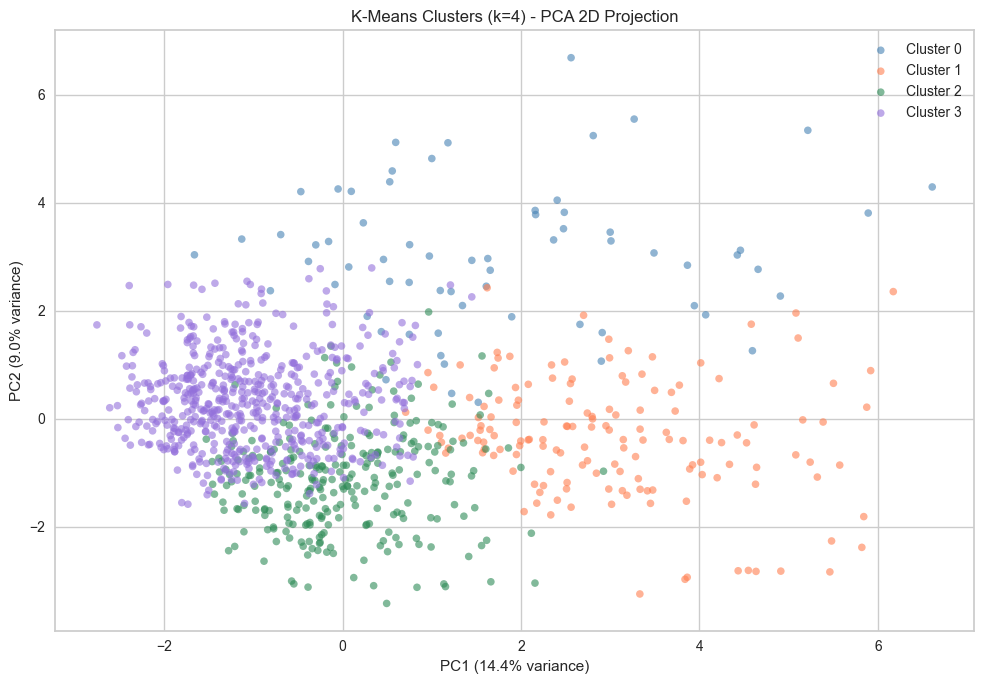

In [11]:
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
cluster_labels = df['cluster'].values

fig, ax = plt.subplots(figsize=(10, 7))

for i in range(4):
    mask = cluster_labels == i
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=colors[i], label=f'Cluster {i}',
               alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('K-Means Clusters (k=4) - PCA 2D Projection')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/clusters_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hierarchical Clustering - Independent Validation

K-Means assumes spherical clusters and is sensitive to initialisation.  
Running hierarchical clustering (Ward linkage) independently gives us a  
second view of the data structure without those assumptions.

Ward linkage minimises the total within-cluster variance at each merge step,  
making it the most comparable method to K-Means for this task.

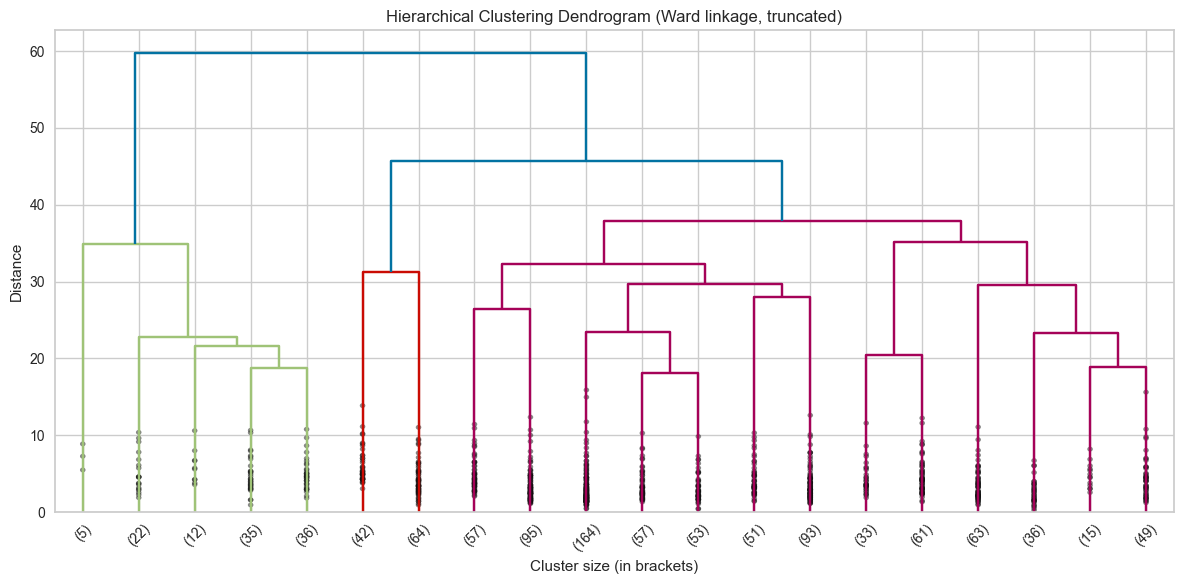

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage, truncated)')
plt.xlabel('Cluster size (in brackets)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('../outputs/figures/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_hc'] = hc.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
print(df['cluster_hc'].value_counts().sort_index())

sil_hc = silhouette_score(X_scaled, df['cluster_hc'])
sil_km = silhouette_score(X_scaled, df['cluster'])
ch_hc = calinski_harabasz_score(X_scaled, df['cluster_hc'])
ch_km = calinski_harabasz_score(X_scaled, df['cluster'])
db_hc = davies_bouldin_score(X_scaled, df['cluster_hc'])
db_km = davies_bouldin_score(X_scaled, df['cluster'])

print(f"\n{'Metric':<25} {'K-Means':<15} {'Hierarchical':<15}")
print(f"{'Silhouette':<25} {sil_km:<15.4f} {sil_hc:<15.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_km:<15.2f} {ch_hc:<15.2f}")
print(f"{'Davies-Bouldin':<25} {db_km:<15.4f} {db_hc:<15.4f}")

Hierarchical cluster sizes:
cluster_hc
0    257
1    110
2    106
3    570
Name: count, dtype: int64

Metric                    K-Means         Hierarchical   
Silhouette                0.0831          0.0824         
Calinski-Harabasz         83.02           66.93          
Davies-Bouldin            2.6317          3.1664         


In [15]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['cluster'], df['cluster_hc'])
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}")
print("(1.0 = perfect agreement, 0.0 = random)")

Adjusted Rand Index (K-Means vs Hierarchical): 0.3166
(1.0 = perfect agreement, 0.0 = random)


**Reading the results:**

The dendrogram shows two large merges at distance ~60 and ~46 - the biggest  
jumps in the tree. A cut at four clusters is visible in the colour separation,  
loosely supporting K=4 from the hierarchical side.

**Metric comparison:**

| Metric | K-Means | Hierarchical |
|---|---|---|
| Silhouette | **0.0831** | 0.0824 |
| Calinski-Harabasz | **83.02** | 66.93 |
| Davies-Bouldin | **2.6317** | 3.1664 |

K-Means wins on all three metrics. Hierarchical is not better here.

**ARI of 0.317** means the two methods agree on cluster assignments about  
32% above random chance. Moderate agreement - both methods find a large  
dominant cluster and a smaller distinct group but disagree on the middle.  
This is expected given the spread variance across 21 dimensions.

**Decision:** K-Means at K=4 is the primary result. Hierarchical served  
its purpose as an independent validation check.

## 7. Cluster Profiling

With K=4 confirmed, we now compute the mean feature values per cluster  
to understand what each segment actually looks like. This is where the  
statistical output becomes a business story.

In [16]:
# use K-Means labels as the primary result
profile = df.drop(columns=['cluster_hc']).groupby('cluster').mean().round(3)

# transpose for readability
profile.T

cluster,0,1,2,3
l1,1.527,1.710,1.332,1.276
k3a,48.258,83.543,64.562,74.159
k3bc,31.364,1.623,0.412,0.326
k3f,8.258,5.099,6.150,8.630
d3c,2.803,5.715,0.810,0.087
d12b,31.439,33.245,11.606,7.739
b5,2003.439,1990.013,2007.318,2008.821
b7,1.366,1.349,1.340,1.287
k82a,0.803,0.146,0.066,0.078
b8,0.182,0.682,0.015,0.002


**Segment profiles from cluster centroids:**

**Cluster 0 - Credit-Reliant Traders (n=66)**  
Highest bank borrowing (31.4%) and loan access (80%) of any segment.  
High foreign inputs (31.4%) and some export activity. Despite having  
credit access, they rate finance and electricity as the most severe  
obstacles. These firms are borrowing to survive infrastructure constraints,  
not to grow.

**Cluster 1 - Formal Export Leaders (n=151)**  
Most sophisticated segment. Oldest firms, largest workforce, highest direct  
exports (5.7%) and foreign input usage (33.2%). 68% hold quality certifications,  
87% have a website, 54% use foreign licensed technology. Primarily self-funded  
at 83% internal capital. They perceive the fewest obstacles - they have the  
resources to absorb constraints that cripple smaller firms.

**Cluster 2 - Domestic Mid-Tier (n=274)**  
Domestically oriented with almost no export or import activity. Very low loan  
access (6.6%) and low technology adoption. They rate obstacles relatively low -  
a stable but unambitious position in the local market. The least differentiated  
profile of all four segments.

**Cluster 3 - Constrained Micro Firms (n=552)**  
Largest segment at 53% of all firms. Smallest in scale, almost entirely domestic,  
near-zero on certs, R&D, website, and foreign tech. Highest finance and electricity  
obstacle scores and strongest informal sector competition. Lowest sales growth.  
This segment represents the base of the Nigerian formal SME pyramid.

### Radar Charts

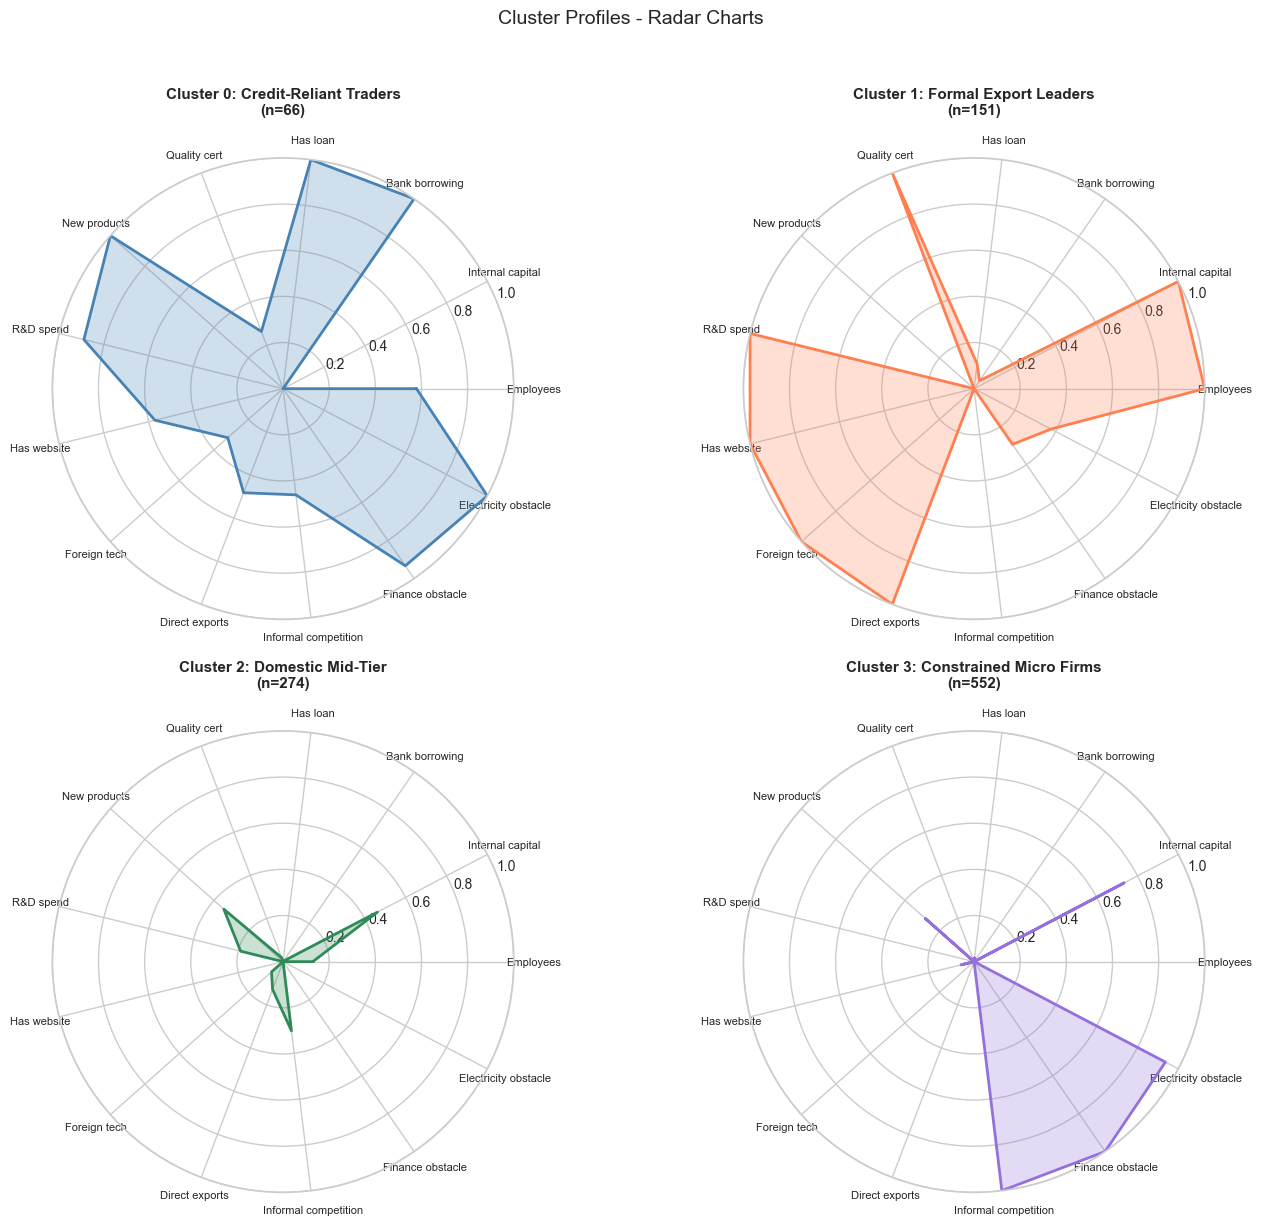

In [17]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# select the most interpretable features for the radar
radar_features = ['l1', 'k3a', 'k3bc', 'k82a', 'b8', 'h1', 
                  'h8', 'c22b', 'e6', 'd3c', 'e11', 'k30', 'c30a']

radar_labels = ['Employees', 'Internal capital', 'Bank borrowing',
                'Has loan', 'Quality cert', 'New products',
                'R&D spend', 'Has website', 'Foreign tech',
                'Direct exports', 'Informal competition',
                'Finance obstacle', 'Electricity obstacle']

cluster_names = ['Credit-Reliant Traders', 'Formal Export Leaders',
                 'Domestic Mid-Tier', 'Constrained Micro Firms']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

# normalise to 0-1 for radar
profile_radar = profile[radar_features].copy()
profile_radar = (profile_radar - profile_radar.min()) / (profile_radar.max() - profile_radar.min())

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, ax in enumerate(axes):
    values = profile_radar.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8)
    ax.set_title(f'Cluster {i}: {cluster_names[i]}\n(n={df["cluster"].value_counts()[i]})',
                 size=11, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Cluster Profiles - Radar Charts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

The radar charts show each segment's shape clearly. Cluster 0 spikes on  
loan and bank borrowing with high obstacle scores. Cluster 1 spikes on  
quality cert, website, and foreign tech - the formality dimensions. Cluster 2  
has the smallest shape across all features. Cluster 3 spikes only on obstacle  
dimensions with everything else flat.

### Key Feature Comparison

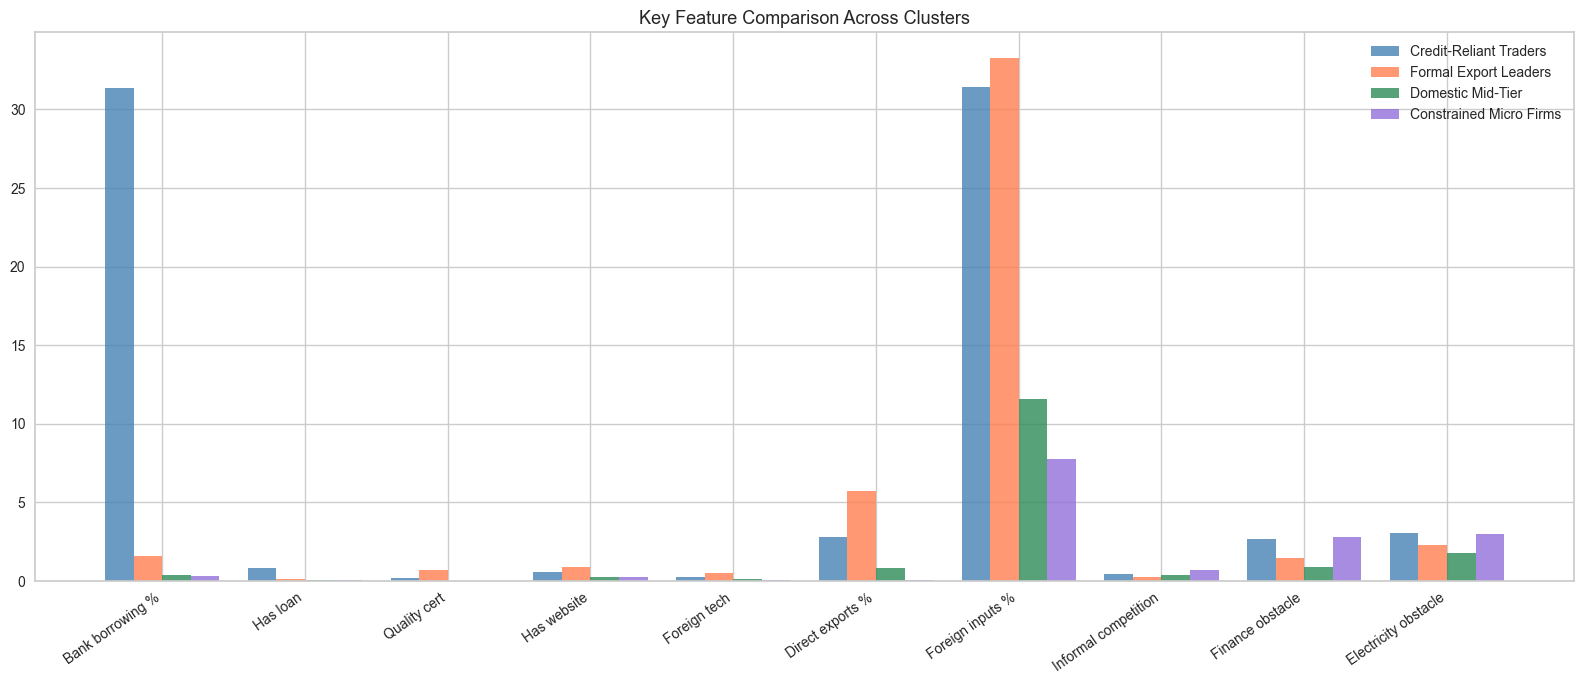

In [18]:
key_features = ['k3bc', 'k82a', 'b8', 'c22b', 'e6', 'd3c', 'd12b', 'e11', 'k30', 'c30a']
key_labels = ['Bank borrowing %', 'Has loan', 'Quality cert', 'Has website',
              'Foreign tech', 'Direct exports %', 'Foreign inputs %',
              'Informal competition', 'Finance obstacle', 'Electricity obstacle']

x = np.arange(len(key_features))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))

for i, (name, color) in enumerate(zip(cluster_names, colors)):
    vals = [profile.iloc[i][f] for f in key_features]
    ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(key_labels, rotation=35, ha='right')
ax.set_title('Key Feature Comparison Across Clusters', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/cluster_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart highlights the two clearest separators: foreign inputs and  
direct exports clearly divide the internationally connected segments (0 and 1)  
from the domestically oriented ones (2 and 3). Bank borrowing isolates  
Cluster 0 from all others.

## 8. Save Labelled Dataset

In [19]:
segment_map = {
    0: 'Credit-Reliant Traders',
    1: 'Formal Export Leaders',
    2: 'Domestic Mid-Tier',
    3: 'Constrained Micro Firms'
}

df['segment'] = df['cluster'].map(segment_map)
df.to_csv('../data/processed/sme_segmented.csv', index=False)

print("Saved to data/processed/sme_segmented.csv")
print(df['segment'].value_counts())

Saved to data/processed/sme_segmented.csv
segment
Constrained Micro Firms    552
Domestic Mid-Tier          274
Formal Export Leaders      151
Credit-Reliant Traders      66
Name: count, dtype: int64


## Summary

Modelling complete. The labelled dataset is saved to `data/processed/sme_segmented.csv`.

**Four segments identified:**

| Segment | n | Share | Key characteristic |
|---|---|---|---|
| Credit-Reliant Traders | 66 | 6% | Bank-dependent, import-heavy, high obstacles |
| Formal Export Leaders | 151 | 14% | Certified, export-active, self-funded |
| Domestic Mid-Tier | 274 | 26% | Local market, low tech, low constraints |
| Constrained Micro Firms | 552 | 53% | Small, domestic, infrastructure-constrained |

**Methodology decisions:**

| Decision | Reason |
|---|---|
| Full features for clustering | PCA explained only 14.4% on PC1 - no dominant axis |
| PCA used for 2D visualisation only | 23.3% variance on 2 components, rough picture only |
| K=4 selected | Balances metrics and interpretability - k=2 too coarse, research precedent |
| K-Means preferred over hierarchical | Better on all three evaluation metrics |
| Silhouette of 0.083 accepted | Consistent with multi-dimensional survey data, not a failure |